In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

DISK_CSV = Path('/home/igor/noise_scaling/modeling/Scaling-up-measurement-noise-scaling-laws/analysis/2026-04-08_veryfing_data_correctness/collect_mi_results_from_disk.csv')
ORIG_CSV = Path('/home/igor/noise_scaling/modeling/Scaling-up-measurement-noise-scaling-laws/collect_mi_results.csv')
DATA_ROOT = Path('/home/igor/noise_scaling/data')

df_disk = pd.read_csv(DISK_CSV)
df_orig = pd.read_csv(ORIG_CSV)

# Collect State MI results from disk using same path convention as collect_mi_results_from_disk.ipynb
EXPECTED = {
    'PBMC':     {'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
                 'qualities': [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422, 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0],
                 'signals': ['protein_counts'], 'seeds': [42, 2303, 2701]},
    'larry':    {'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
                 'qualities': [0.003876, 0.0071835, 0.0133136, 0.0246748, 0.0457311, 0.0847557, 0.1570821, 0.2911284, 0.5395631, 1.0],
                 'signals': ['clone'], 'seeds': [42, 1404, 2701]},
    'merfish':  {'sizes': [100, 203, 414, 843, 1716, 3494, 7113, 14480, 29475, 60000],
                 'qualities': [0.027248, 0.0406617, 0.0606789, 0.0905502, 0.1351267, 0.2016475, 0.3009156, 0.4490518, 0.6701133, 1.0],
                 'signals': ['ng_idx'], 'seeds': [1404, 2303, 2701]},
    'shendure': {'sizes': [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000],
                 'qualities': [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384, 0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0],
                 'signals': ['author_day'], 'seeds': [42]},
}

# Scan for all State MI results on disk (any dataset/size/quality/seed)
state_rows = []
for mi_file in DATA_ROOT.rglob('results/State/model/MI/*/Y_*/lmi_mutual_information.txt'):
    parts = mi_file.parts
    idx = parts.index('results')
    quality = parts[idx - 1]
    size = parts[idx - 2]
    dataset = parts[idx - 3]
    seed = parts[idx + 4]
    signal_raw = parts[idx + 5]  # e.g. Y_ng_idx_1.0
    # Parse signal: strip Y_ prefix and quality suffix
    sig = signal_raw.replace('Y_', '')
    sig_parts = sig.rsplit('_', 1)
    try:
        float(sig_parts[-1])
        sig = sig_parts[0]
    except ValueError:
        pass
    # Skip cur_idx signal
    if sig == 'cur_idx':
        continue
    try:
        mi_val = float(mi_file.read_text().strip())
    except Exception:
        continue
    state_rows.append({
        'dataset': dataset, 'size': int(size), 'quality': float(quality),
        'algorithm': 'State', 'signal': sig, 'seed': int(seed), 'mi_value': mi_val,
    })

df_state = pd.DataFrame(state_rows)
print(f'State results from disk: {len(df_state)} rows')
if len(df_state) > 0:
    display(df_state)

# Append State to disk results
df_disk = pd.concat([df_disk, df_state], ignore_index=True)

ALGOS = ['Geneformer', 'PCA', 'RandomProjection', 'SCVI', 'State']

def filter_to_expected(df):
    masks = []
    for ds, cfg in EXPECTED.items():
        m = ((df['dataset'] == ds) &
             df['size'].isin(cfg['sizes']) &
             df['quality'].isin(cfg['qualities']) &
             df['signal'].isin(cfg['signals']) &
             df['seed'].isin(cfg['seeds']) &
             df['algorithm'].isin(ALGOS))
        masks.append(m)
    # Keep all State rows regardless of expected seeds/sizes
    masks.append(df['algorithm'] == 'State')
    return df[pd.concat(masks, axis=1).any(axis=1)].copy()

df_disk = filter_to_expected(df_disk)
df_orig = filter_to_expected(df_orig)

print(f'Disk:  {len(df_disk)} rows — algos: {sorted(df_disk["algorithm"].unique())}')
print(f'Orig:  {len(df_orig)} rows — algos: {sorted(df_orig["algorithm"].unique())}')

In [14]:
def plot_mi_scaling_side_by_side(df_orig, df_disk):
    """Plot MI vs number of cells: rows=dataset×signal, cols=algorithm, each split into NVIDIA|AMD."""
    all_ds_sig = sorted(
        set(zip(df_orig['dataset'], df_orig['signal'])) | set(zip(df_disk['dataset'], df_disk['signal']))
    )
    algorithms = sorted(set(df_orig['algorithm'].unique()) | set(df_disk['algorithm'].unique()))
    n_rows = len(all_ds_sig)
    n_col_pairs = len(algorithms)

    source_labels = ['Original (NVIDIA)', 'Regenerated (AMD)']
    source_edge_colors = ['#2166ac', '#b2182b']

    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

    fig = plt.figure(figsize=(3.4 * n_col_pairs * 2, 3.5 * n_rows + 1.2))
    outer_gs = GridSpec(n_rows, n_col_pairs, figure=fig,
                        top=0.90, bottom=0.06, left=0.08, right=0.88,
                        hspace=0.35, wspace=0.4)

    axes = np.empty((n_rows, n_col_pairs * 2), dtype=object)
    for i in range(n_rows):
        for j in range(n_col_pairs):
            inner_gs = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[i, j], wspace=0.08)
            axes[i, j * 2] = fig.add_subplot(inner_gs[0, 0])
            axes[i, j * 2 + 1] = fig.add_subplot(inner_gs[0, 1])

    for i in range(n_rows):
        for jj in range(1, n_col_pairs * 2):
            axes[i, jj].sharey(axes[i, 0])

    all_qualities = sorted(set(df_orig['quality'].unique()) | set(df_disk['quality'].unique()))
    norm = mcolors.LogNorm(vmin=min(all_qualities), vmax=max(all_qualities))
    cmap = plt.cm.viridis

    sources = [(source_labels[0], df_orig), (source_labels[1], df_disk)]

    for i, (ds, sig) in enumerate(all_ds_sig):
        for j, algo in enumerate(algorithms):
            for s, (src_name, df_src) in enumerate(sources):
                ax = axes[i, j * 2 + s]
                sub = df_src[(df_src['dataset'] == ds) & (df_src['algorithm'] == algo) & (df_src['signal'] == sig)]

                for spine in ax.spines.values():
                    spine.set_edgecolor(source_edge_colors[s])
                    spine.set_linewidth(2)

                if sub.empty:
                    ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                            transform=ax.transAxes, color='gray', fontsize=10)
                    ax.set_xscale('log')
                else:
                    for q in sorted(sub['quality'].unique()):
                        color = cmap(norm(q))
                        q_df = sub[sub['quality'] == q]
                        agg = q_df.groupby('size')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
                        agg = agg.sort_values('size')
                        agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
                        ax.errorbar(agg['size'], agg['mean'], yerr=agg['sem'],
                                    marker='o', markersize=2.5, linewidth=0.9, capsize=1.5,
                                    color=color, alpha=0.85)
                    ax.set_xscale('log')

                if i == n_rows - 1:
                    ax.set_xlabel('Number of cells', fontsize=9)
                if j == 0 and s == 0:
                    ax.set_ylabel(f'MI value ({sig})', fontsize=9)
                if i == 0:
                    ax.set_title(src_name, fontsize=7, color=source_edge_colors[s], fontweight='bold')
                if j == 0 and s == 0:
                    ax.annotate(ds, xy=(0, 0.5), xytext=(-0.55, 0.5),
                                xycoords='axes fraction', textcoords='axes fraction',
                                fontsize=12, fontweight='bold', ha='center', va='center', rotation=90)
                ax.tick_params(labelsize=7)
                if not (j == 0 and s == 0):
                    ax.tick_params(labelleft=False)

    # Algorithm group labels
    for j, algo in enumerate(algorithms):
        left_pos = axes[0, j * 2].get_position()
        right_pos = axes[0, j * 2 + 1].get_position()
        cx = (left_pos.x0 + right_pos.x1) / 2
        cy = left_pos.y1 + 0.035
        fig.text(cx, cy, algo, ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='white', edgecolor=c, linewidth=2.5, label=l)
                       for l, c in zip(source_labels, source_edge_colors)]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, bbox_to_anchor=(0.99, 0.99))

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.5])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Quality (downsampling ratio)', fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    fig.suptitle('MI vs Number of Cells — Original (NVIDIA) vs Regenerated (AMD)',
                 fontsize=14, fontweight='bold', y=0.99)
    plt.show()
    return fig

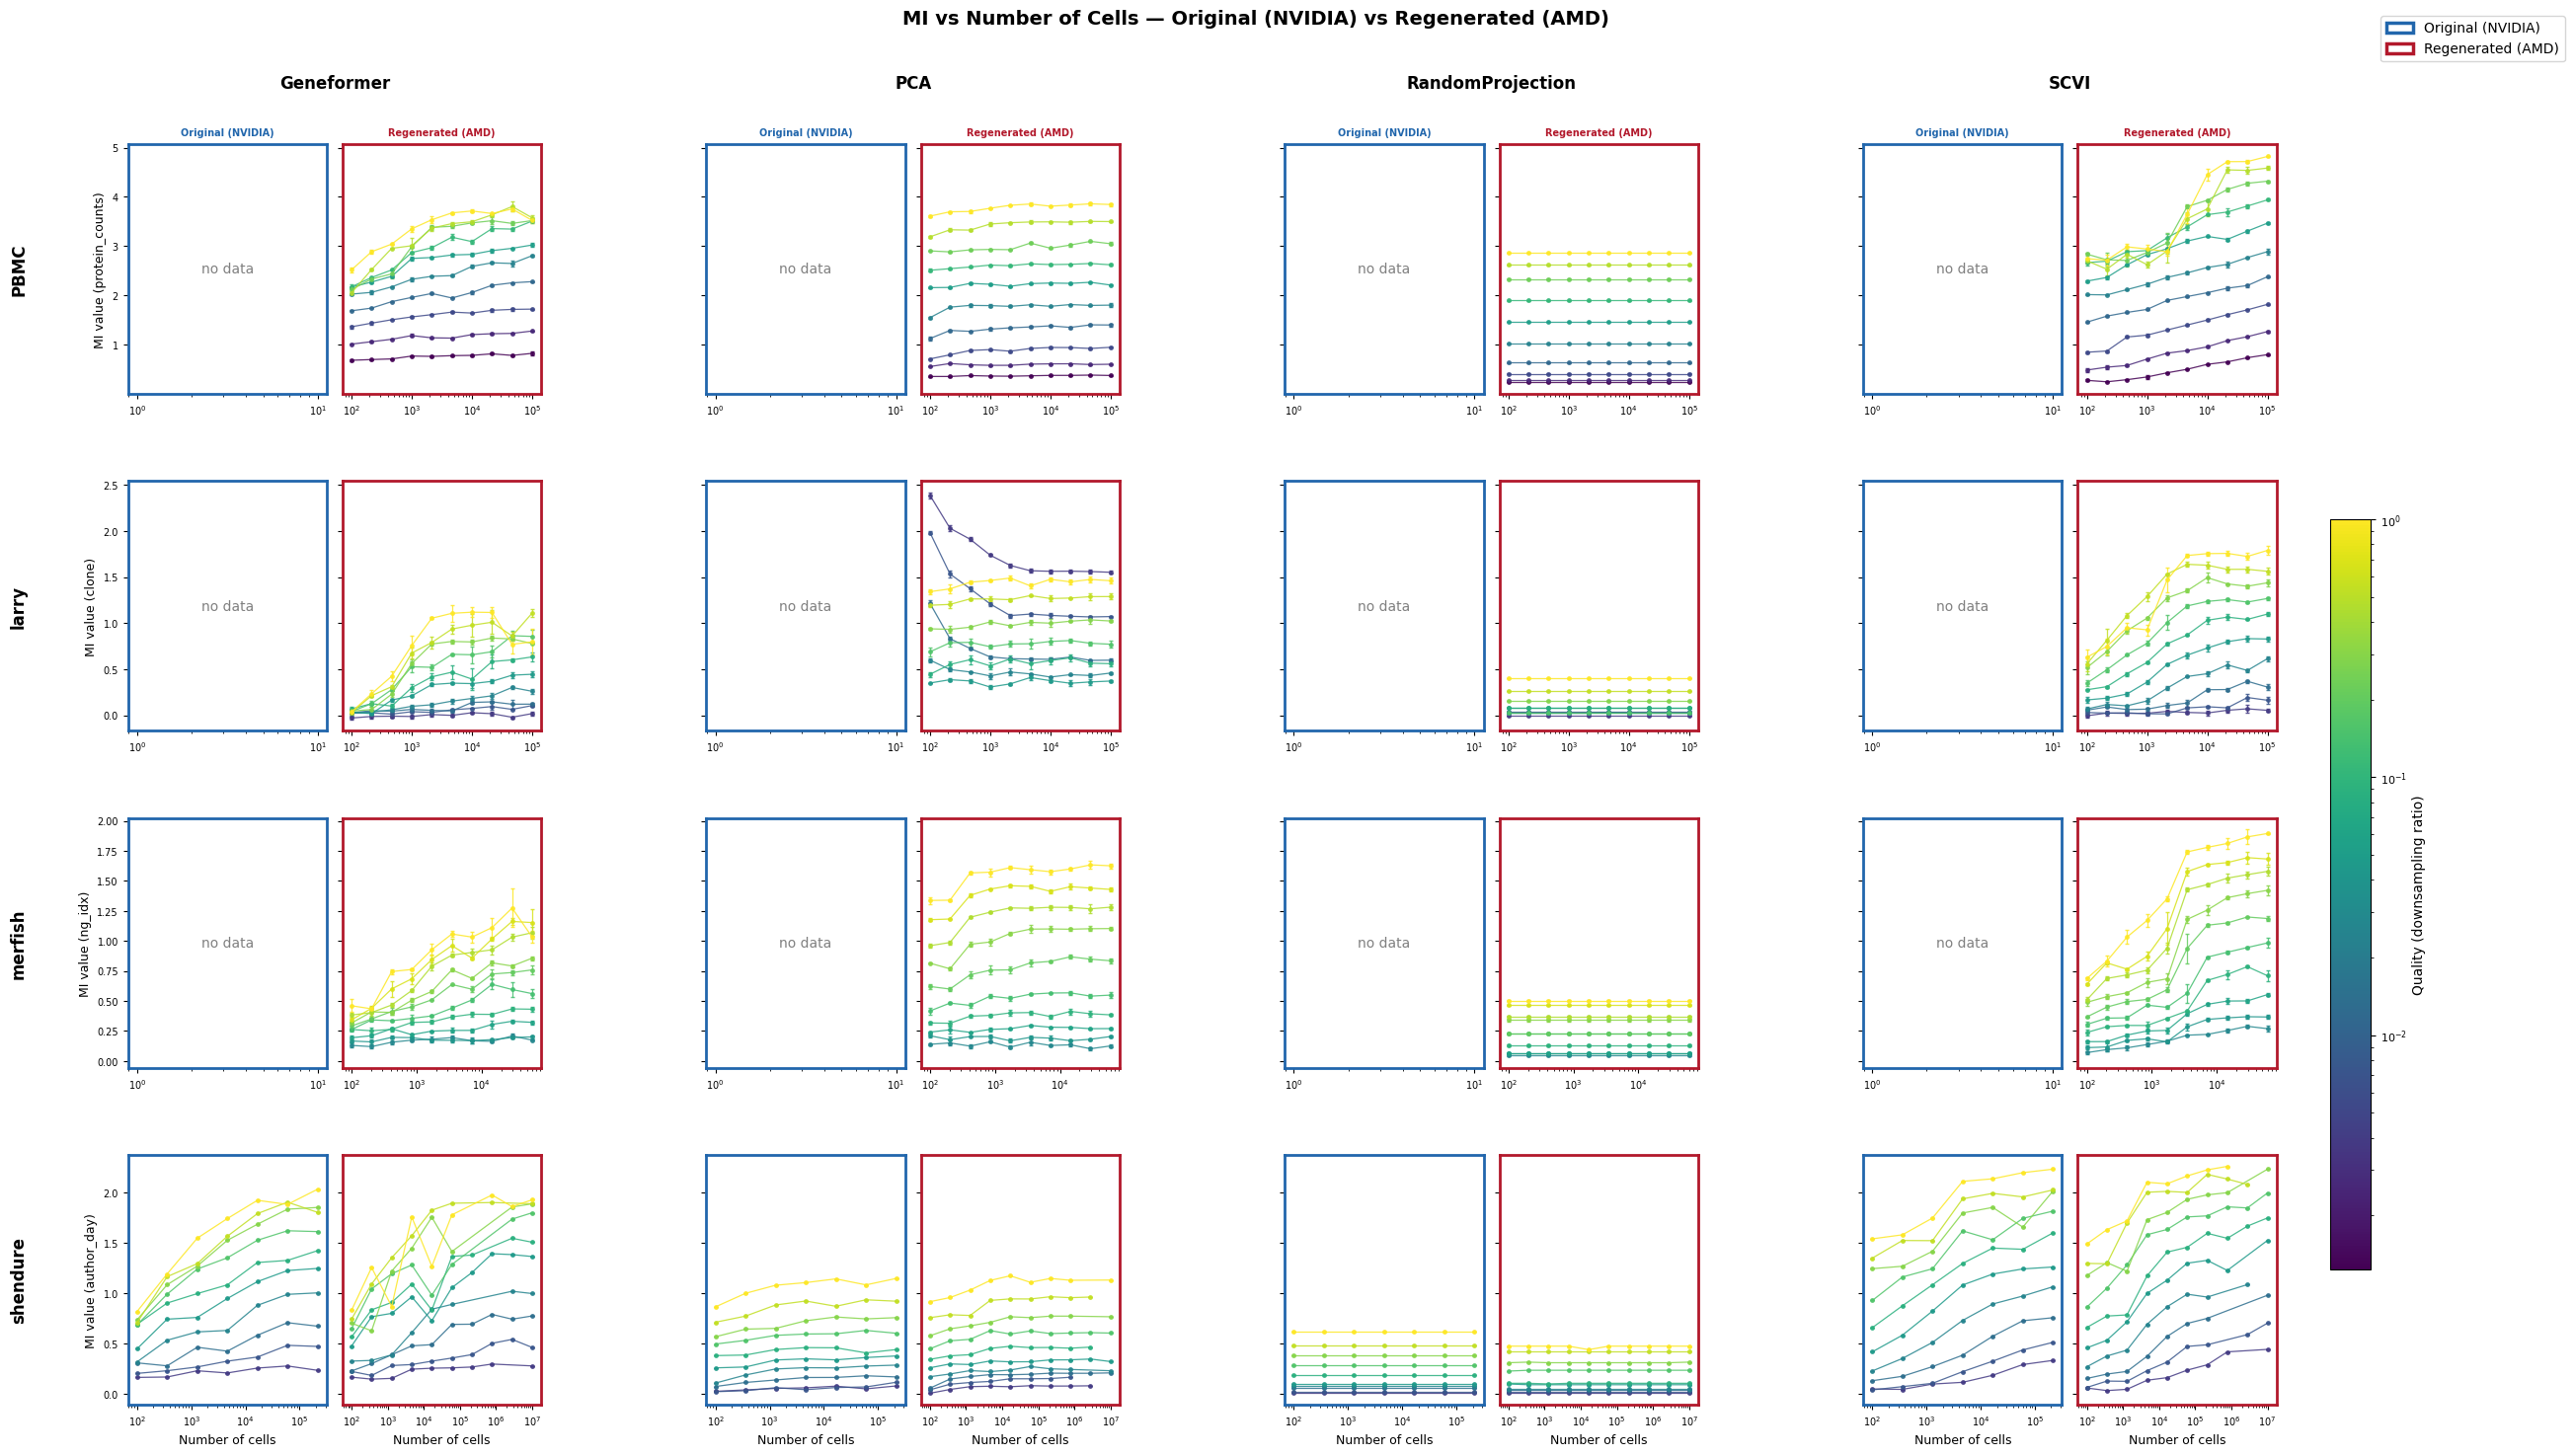

In [15]:
fig = plot_mi_scaling_side_by_side(df_orig, df_disk)

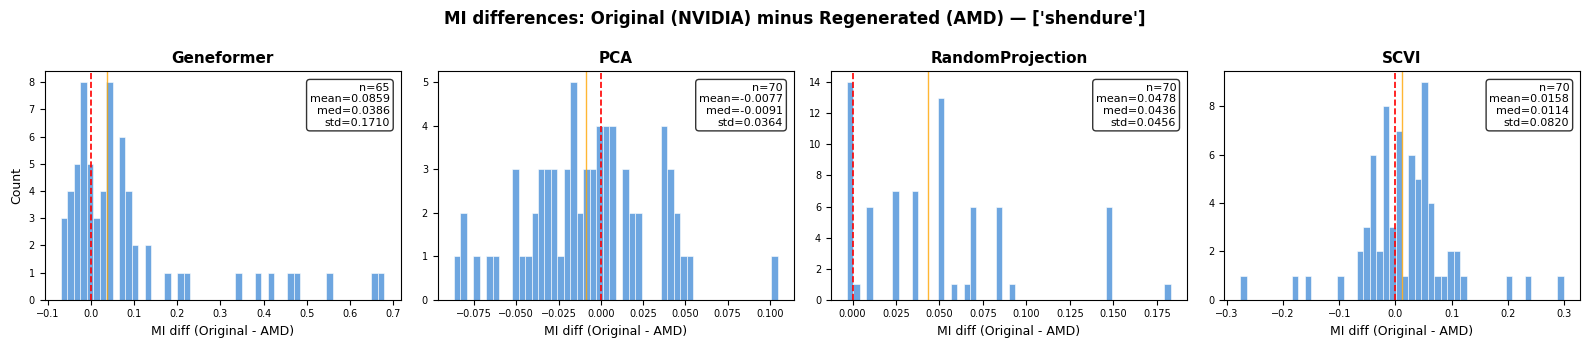

Matched 275 points across ['shendure']


In [16]:
# Point-matched difference distribution (only for shendure where both sources have data)
join_cols = ['dataset', 'size', 'quality', 'algorithm', 'signal', 'seed']
matched = df_orig.merge(df_disk, on=join_cols, suffixes=('_orig', '_amd'))
matched['mi_diff'] = matched['mi_value_orig'] - matched['mi_value_amd']

algorithms = sorted(matched['algorithm'].unique())

fig, axes = plt.subplots(1, len(algorithms), figsize=(4 * len(algorithms), 3.5), squeeze=False)

for j, algo in enumerate(algorithms):
    ax = axes[0, j]
    sub = matched[matched['algorithm'] == algo]

    if sub.empty:
        ax.text(0.5, 0.5, 'no matched\npoints', ha='center', va='center',
                transform=ax.transAxes, color='gray')
    else:
        ax.hist(sub['mi_diff'], bins=50, color='#4a90d9', edgecolor='white',
                linewidth=0.5, alpha=0.8)
        ax.axvline(0, color='red', ls='--', lw=1.2)
        med = sub['mi_diff'].median()
        mean = sub['mi_diff'].mean()
        std = sub['mi_diff'].std()
        ax.axvline(med, color='orange', ls='-', lw=1, alpha=0.8)
        ax.text(0.97, 0.95,
                f'n={len(sub)}\nmean={mean:.4f}\nmed={med:.4f}\nstd={std:.4f}',
                transform=ax.transAxes, fontsize=8, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_title(algo, fontsize=11, fontweight='bold')
    ax.set_xlabel('MI diff (Original - AMD)', fontsize=9)
    if j == 0:
        ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle(f'MI differences: Original (NVIDIA) minus Regenerated (AMD) — {sorted(matched["dataset"].unique())}',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()
print(f'Matched {len(matched)} points across {sorted(matched["dataset"].unique())}')